## 01211373 : Machine Learning and Programming for Industry

### Lecture 2 and 3 Supplement: Linear and Logistic Regression

Linear and logistic regression covered in this lecture are perhaps 
the most basic approach in machine learning. They are a subclass of 
supervised learning. The term "regression" may be confusing when some tries to relate it to the underlying mathematics. Here is 
some explanation from AI 

"The term "regression" in statistics comes from Sir Francis Galton's observations about heredity, specifically the tendency of offspring to regress towards the mean of a population. In the late 1800s, Galton studied the relationship between parents' and children's heights and noticed that exceptionally tall or short parents tended to have children whose heights were closer to the average height of the population. This "regression towards the mean" is the origin of the term, which later evolved into the broader statistical concept of regression analysis." 

### 3.1 Simple Linear Regression

A general description for linear regression in this course is a hypothesis (or model) $h_\theta(x)$ 
that maps features $x \in \mathbb{R}^d$, where $d$ is dimension of features, to $y \in \mathbb{R}$;i.e., a continuous variable. Our job is to find $h_\theta(x)$ to give the best fit for given data. It might be a straigt line, quadratic function, or higher-order.

**Note :** Previously we use $w_i$ and $b$ to represent weight and bias in the perceptron and adaline. In the linear and logistic regression literature $\theta$ is often used in a hypothesis. In the discussion that follows, you can think of $b$ as $\theta_0$ and $w_i = \theta_i$ for $i = 1,2, \ldots$.

Here we start from a simple case when the feature is only one dimensional, such as judging house price based only on the size of house. Suppose we want to approximate $y$ as a linear function of $x$

$$
h_\theta(x) = \theta_0 + \theta_1x_1 \tag{3.1}
$$

$\theta_i$ are called parameters or weights. When there is no confusion we write $h_\theta(x)$ simply as $h(x)$. To simplify notation further, let $x_0 = 1$ (called *intercept term*) so that

$$
h(x) = \sum_{i=0}^d \theta_ix_i = \theta^Tx \tag{3.2}
$$

Here $d$ is the number of input variables (not counting $x_0$). 

Define a **cost function** to measure how close $h(x^{(i)})$ are to $y^{(i)}$
$$
J(\theta) = \frac{1}{2}\sum_{i=1}^n\big(h_\theta(x^{(i)}) - y^{(i)}\big)^2 \tag{3.3}
$$

Note this is the familiar least-squares cost function that gives rise to the **ordinary least square** regression model. 

### 3.1.1 LMS algorithm

**Objective :** Choose $\theta$ to minimize $J(\theta)$

#### Gradient descent 

* start with some initial guess for $\theta$
* Update $\theta$ to minimize $J(\theta)$

$$
\theta_j := \theta_j - \alpha\frac{\partial} {\partial \theta_j} J(\theta),\;\; j = 0,\ldots,d \tag{3.4}
$$
Here $\alpha$ is called *learning rate*. 

It is shown in [2] that
$$
\frac{\partial} {\partial \theta_j} J(\theta) = (h_\theta(x)-y)x_j \tag{3.5}
$$

Hence, the LMS update rule for single training example becomes
$$
\theta_j := \theta_j + \alpha\big(y^{(i)} - h_\theta(x^{(i)})\big)x_j^{(i)} \tag{3.6}
$$
a.k.a **Widrow-Hoff** learning rule.

For the whole data set, the algorithm becomes

Repeat until convergence   {
$$
\theta_j := \theta_j + \alpha\sum_{i=1}^n\big(y^{(i)} - h_\theta(x^{(i)})\big)x_j^{(i)}, \;\; j = 0,\ldots,d \tag{3.7}
$$
}


Or, compactly with $\theta$ in vector form

$$
\theta := \theta + \alpha\sum_{i=1}^n\big(y^{(i)} - h_\theta(x^{(i)})\big)x^{(i)} \tag{3.8}
$$


### Dataset

The dataset we'll experiment with is from 

https://www.kaggle.com/datasets?tags=13405-Linear+Regression 

where we start from a simple one such as

https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression/data 

In this Salary Dataset, salary depends only on the experience in years.

You may need to install kagglehub 

```python
!pip install kagglehub
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

print("Path to dataset files:", path)

c:\Users\dewpl\.julia\conda\3\x86_64\envs\mlpi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\dewpl\.cache\kagglehub\datasets\abhishek14398\salary-dataset-simple-linear-regression\versions\1


In [3]:
try:
    df = pd.read_csv(os.path.join(path, "Salary_dataset.csv"))
except FileNotFoundError:
    print("Error: electricity_cost_dataset.csv not found. Please ensure the dataset is in the same directory.")
    exit()

**Note :** If the above code fail, you may download Salary_dataset.csv manually and place it in the same directory as this notebook. 
Then read it to dataframe.

```python
df = pd.read_csv('Salary_dataset.csv') 
```

In [4]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


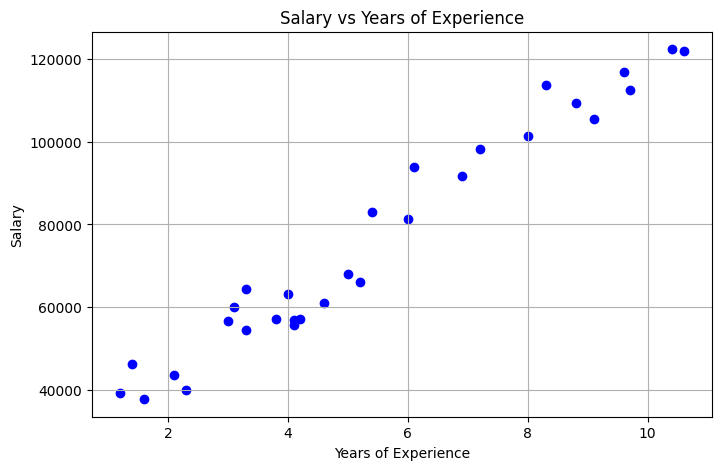

In [6]:
# Visualize data
plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience')
plt.grid(True)
plt.show()

In [7]:
X = df['YearsExperience'].to_numpy()
nrows = X.shape[0]
X = X.reshape(nrows,1)
y = df['Salary'].to_numpy()
X = np.hstack((np.ones((nrows,1)),X)) # append x_0 = 1 to data 
print("Shape of X (features): " + str(X.shape))
y = y.reshape(nrows,1)
print("Shape of y (target) : " + str(y.shape))

Shape of X (features): (30, 2)
Shape of y (target) : (30, 1)


In [8]:
# modification of OOP implementation from chapter 9 of book to fit this example. 
# Add step() method.

class LinearRegressionGD:
    def __init__(self, alpha=0.01, n_iter=50):
        self.alpha = alpha
        self.n_iter = n_iter
        self.iter = 1 # updated each epoch
        self.theta = np.array([0.0,0.0]).reshape(2,1)

        self.losses_ = []

    def step(self, X, y):
        # Step trhough one episode
        print("Epoch : " + str(self.iter))

        output = self.net_input(X)
        errors = (y - output)
        self.theta += self.alpha*X.T.dot(errors)
        loss = (errors**2).mean()
        self.losses_.append(loss)
        print("Loss = "+str(loss))
        self.iter += 1
        return self


    def fit(self, X, y):

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.theta += self.alpha*X.T.dot(errors)
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        return np.dot(X, self.theta)

    def predict(self, X):
        return self.net_input(X)


In [16]:
# create function to plot hypothesis v.s. data
def plot_prediction(X,y,model):
    plt.figure(figsize=(8, 5))
    # plt.scatter(df['YearsExperience'], df['Salary'], color='blue')
    plt.scatter(X[:,1],y,color='blue',label='data')
    plt.plot(X[:,1],model.predict(X),color='orange',label='prediction')
    plt.xlabel('Years of Experience')
    plt.ylabel('Salary')
    plt.title('Salary vs Years of Experience')
    plt.grid(True)
    plt.legend()
    plt.show()    

Test with step() method.

In [17]:
lr = LinearRegressionGD(alpha=0.001)

Epoch : 1
Loss = 6503107277.733334
theta = 
[[ 2280.12  ]
 [14550.1324]]


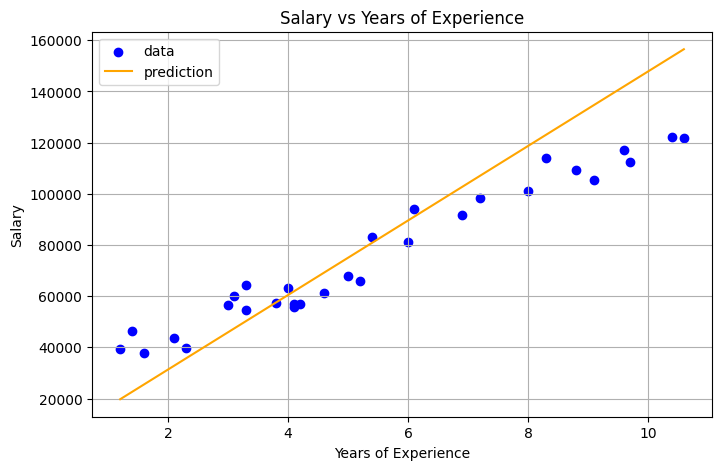

In [18]:
lr.step(X,y)
print("theta = ")
print(lr.theta)
plot_prediction(X,y,lr)

Test with fit() method.

In [19]:
lr = LinearRegressionGD(alpha=0.001,n_iter=50) # changing n_iter to see results

In [20]:
lr.fit(X,y)
print("theta = ")
print(lr.theta)

theta = 
[[ 7990.06636344]
 [11924.18237407]]


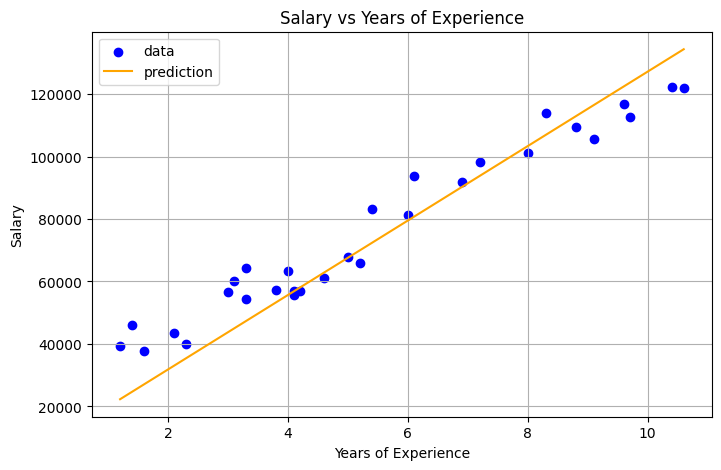

In [21]:
plot_prediction(X,y,lr)

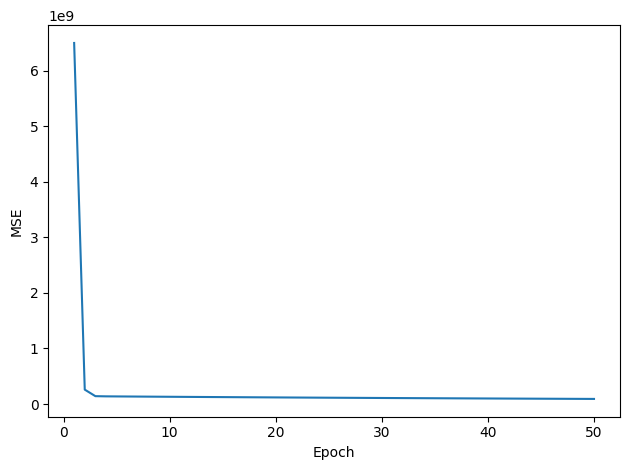

Final loss =91674109.59586747


In [22]:
plt.plot(range(1, lr.n_iter+1), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()
print("Final loss =" + str(lr.losses_[-1]))

### 3.1.2 Normal equations

Instead of using gradient descent to minimize $J$, for this linear regression problem we can 
find the solution right away. It's a global minimum since the LMS cost is convex. The details are 
in section 1.2 of [2]. Here we just state the normal equations
$$
X^TX\theta = X^Ty \tag{3.9}
$$

Thus, the value of $\theta$ that minimizes $J(\theta)$ is given in closed form by the equation
$$
\theta = (X^TX)^{-1}X^Ty \tag{3.10}
$$


In [13]:
theta_ls = np.linalg.inv(X.T@X)@X.T@y
theta_ls

array([[24848.20396652],
       [ 9449.96232146]])

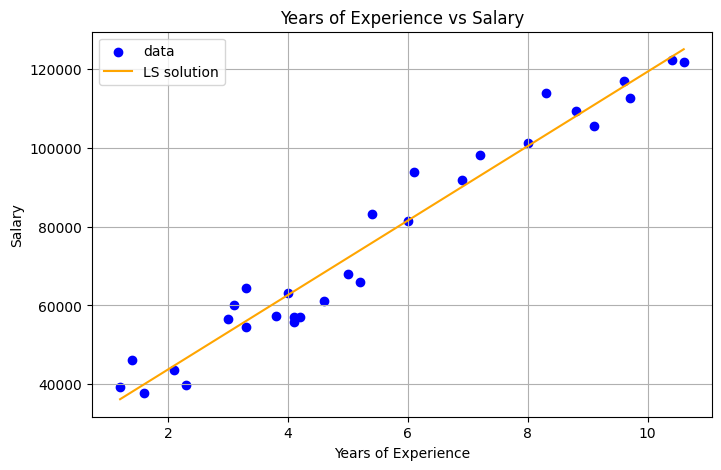

In [14]:
plt.figure(figsize=(8, 5))
# plt.scatter(df['YearsExperience'], df['Salary'], color='blue')
plt.scatter(X[:,1],y,color='blue',label='data')
y_pred = np.dot(X,theta_ls) 
plt.plot(X[:,1],y_pred,color='orange',label='LS solution')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Years of Experience vs Salary')
plt.grid(True)
plt.legend()
plt.show()    

In [15]:
# compared to theta values from gradient descent
lr = LinearRegressionGD(alpha=0.001,n_iter=1000)
lr.fit(X,y)
lr.theta

array([[24800.84815138],
       [ 9456.91259735]])

In [16]:
theta_ls

array([[24848.20396652],
       [ 9449.96232146]])

#### Example from chapter 9 of [1]

#### Exploring the Ames Housing dataset

The Ames Housing dataset contains information about individual residential property in Ames, Iowa, 2006 - 2010. The dataset consists of 2,930 examples and 80 features. For simplicity, we will only work with a subset of the features. 

* Overall Qual : rating for overall material and finish, from 1 (very poor) to 10 (excellent)
* Overall Cond : rating for overall condition, trom 1 (very poor) to 10 (excellent)
* Gr Liv area : Above ground living area in square feet
* Central Air : Central air conditioning (N = no, Y = yes)
* Total Bsmt SF: Total square feet of the basement area
* SalePrice : Sale price in USD 

We will regard SalePrice as our target variable.

Let's load it into a pandas DataFrame:


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [24]:
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
           'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv('http://jse.amstat.org/v19n3/decock/AmesHousing.txt', 
                 sep='\t',
                 usecols=columns)

df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [25]:
df.shape

(2930, 6)

Use .map() method to convert DataFrame columns from 'Y' to 1, and 'N' to 0.

In [26]:
df['Central Air'] = df['Central Air'].map({'N': 0, 'Y': 1})

Check whether any of the data frame columns contain missing values.

In [27]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [28]:
# remove rows that contain missing values

df = df.dropna(axis=0)
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

### Visualizing the important characteristics of a dataset

Exploratory data analysis (EDA) via mlxtend library, created by Sebastian Raschka.

In [31]:
# You may need to install mlxtend 
# !pip install mlxtend

In [32]:
from mlxtend.plotting import scatterplotmatrix

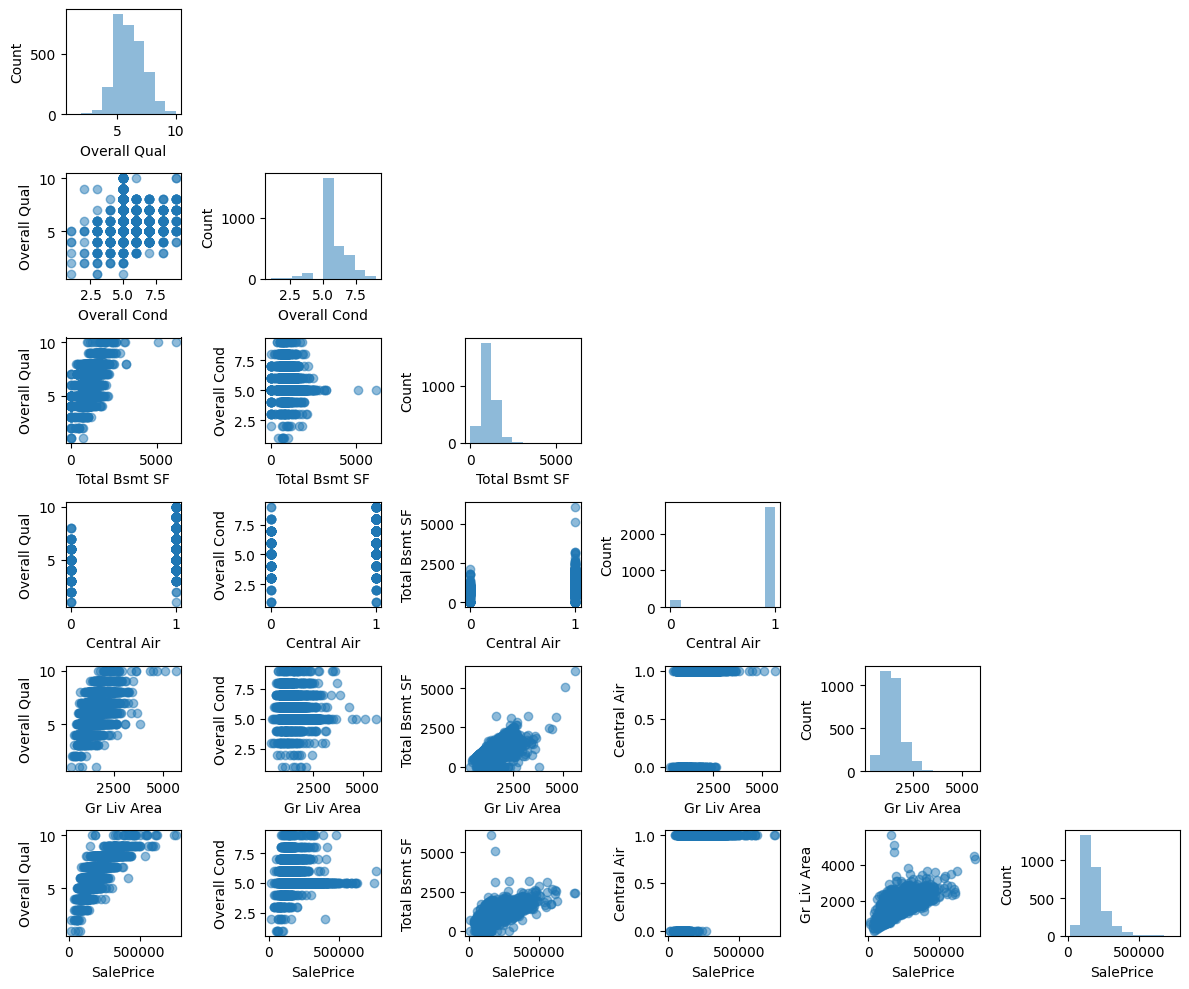

In [33]:
scatterplotmatrix(df.values, figsize=(12, 10), 
                  names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()

### Looking at relationships using a correlation matrix

r : Pearson product-moment correlation coefficient (also called Pearson's r) range -1 to 1

* r = 1 : perfect positive correlation
* r = 0 : no correlation                                               
* r = -1 : perfect negative correlation


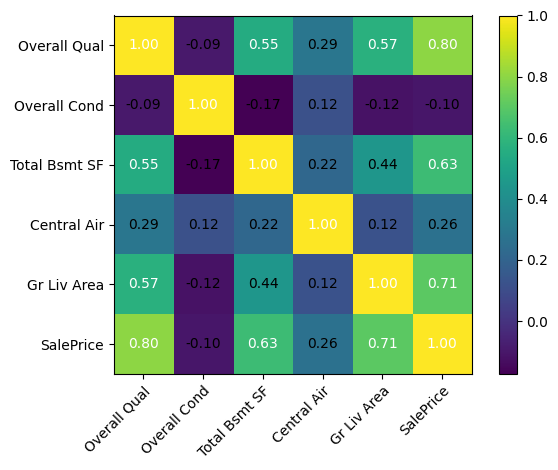

In [34]:
from mlxtend.plotting import heatmap
cm = np.corrcoef(df.values.T)
hm = heatmap(cm, row_names=df.columns, column_names=df.columns)
plt.tight_layout()
plt.show()

##### Solving regression for regression parameters with gradient descent.



In [35]:
class LinearRegressionGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.array([0.])
        self.losses_ = []

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return self.net_input(X)

In [36]:
X = df[['Gr Liv Area']].values
y = df['SalePrice'].values

In [37]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
X_std = sc_x.fit_transform(X)
y_std = sc_y.fit_transform(y[:, np.newaxis]).flatten()

In [38]:
lr = LinearRegressionGD(eta=0.1)
lr.fit(X_std, y_std)

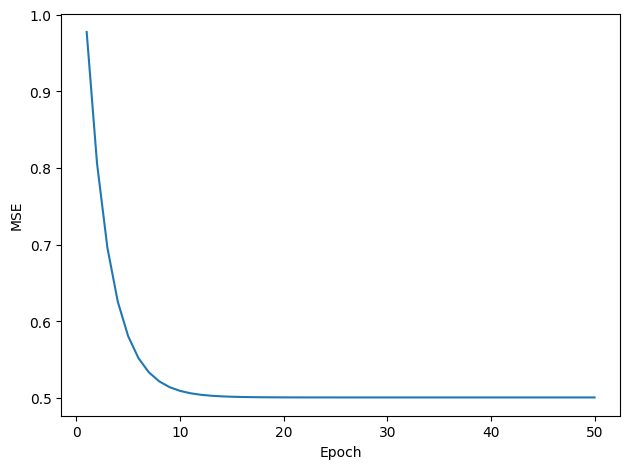

In [39]:
plt.plot(range(1, lr.n_iter+1), lr.losses_)
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

In [40]:
def lin_regplot(X, y, model):
    plt.scatter(X, y, c='steelblue', edgecolor='white', s=70)
    plt.plot(X, model.predict(X), color='black', lw=2)    
    return 

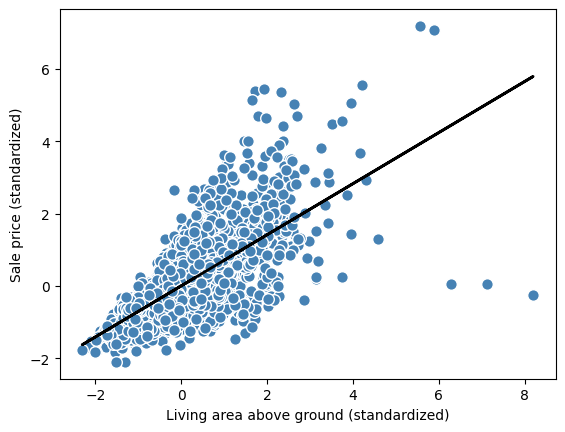

In [41]:
lin_regplot(X_std, y_std, lr)
plt.xlabel('Living area above ground (standardized)')
plt.ylabel('Sale price (standardized)')
plt.show()

In [42]:
feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(-1, 1))
print(f'Sale price: ${target_reverted.flatten()[0]:.2f}')

Sale price: $292507.07


In [35]:
print(f'Slope: {lr.w_[0]:.3f}')
print(f'Intercept: {lr.b_[0]:.3f}')

Slope: 0.707
Intercept: -0.000


##### Linear regression with scikit-learn

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
print(f'Slope: {slr.coef_[0]:.3f}')
print(f'Intercept: {slr.intercept_:.3f}')

Slope: 111.666
Intercept: 13342.979


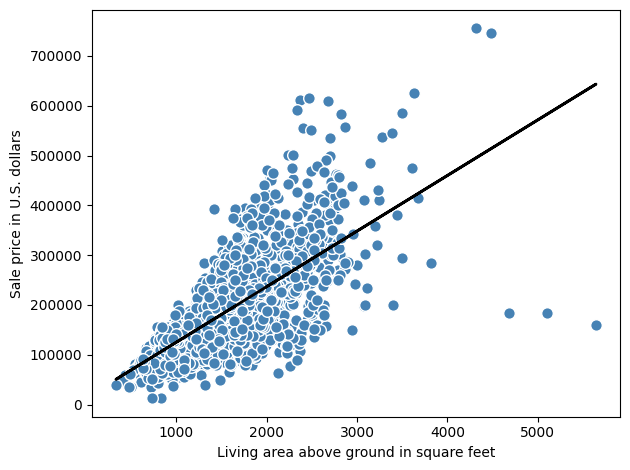

In [38]:
lin_regplot(X, y, slr)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')

plt.tight_layout()
plt.show()

##### Normal equations

In [39]:
# adding a column vector of "ones"
Xb = np.hstack((np.ones((X.shape[0], 1)), X))
w = np.zeros(X.shape[1])
z = np.linalg.inv(np.dot(Xb.T, Xb))
w = np.dot(z, np.dot(Xb.T, y))

print(f'Slope: {w[1]:.3f}')
print(f'Intercept: {w[0]:.3f}')

Slope: 111.666
Intercept: 13342.979


### 3.1.4 Probabilistic interpretation

From section 1.3 (p.15) of [2]

Why is least-square cost function $J$ a reasonable choice ?

Assume the target variables and inputs are related via the equation
$$
y^{(i)} = \theta^Tx^{(i)} + \epsilon^{(i)} \tag{3.11}
$$

where $\epsilon^{(i)}$ captures unmodeled errors, or random noise. Let's assume that $\epsilon^{(i)}$ 's are Gaussian's i.i.d (independently and identically distributed), also called Normal distribution, with zero mean and variance $\sigma^2$. We can write it as $\epsilon^{(i)} \sim \mathcal{N}(0,\sigma^2)$; i.e., the density of $\epsilon^{(i)}$ is given by 
$$
p(\epsilon^{(i)}) = \frac{1}{\sqrt{2\pi\sigma}}exp\left(-\frac{(\epsilon^{(i)})^2}{2\sigma^2}\right) \tag{3.12}
$$

This implies that
$$
p(y^{(i)}|x^{(i)};\theta) = \frac{1}{\sqrt{2\pi\sigma}}exp\left(-\frac{(y^{(i)}-\theta^Tx^{(i)})^2}{2\sigma^2}\right) \tag{3.13}
$$

**Note :** This is read as "probability of $y^{(i)}$ given $x^{(i)}$ parameterized by $\theta$ [2].

Define the likelihood function
$$
L(\theta) = p(y|X; \theta) \tag{3.14}
$$

Since $\epsilon^{(i)}$ is i.i.d 
$$
\begin{align*}
L(\theta) &= \prod_{i=1}^{n}p(y^{(i)}|x^{(i)};\theta) \\
&= \prod_{i=1}^{n}\frac{1}{\sqrt{2\pi\sigma}}exp\left(-\frac{(y^{(i)}-\theta^Tx^{(i)})^2}{2\sigma^2}\right) \tag{3.15}
\end{align*}
$$

By the principle of **maximum likelihood**, we want to choose $\theta$ to maximize $L(\theta)$. We can also choose to maximize any monotonically increasing function of $L(\theta)$. In particular, the derivations will be simpler if we instead maximize the **log likelihood** $l(\theta)$.
$$
\begin{align*}
l(\theta) &= log L(\theta) \\
&= log \prod_{i=1}^{n}\frac{1}{\sqrt{2\pi\sigma}}exp\left(-\frac{(y^{(i)}-\theta^Tx^{(i)})^2}{2\sigma^2}\right) \\
&= \sum_{i=1}^n log \frac{1}{\sqrt{2\pi\sigma}}exp\left(-\frac{(y^{(i)}-\theta^Tx^{(i)})^2}{2\sigma^2}\right) \\
&= n \; log \frac{1}{\sqrt{2\pi\sigma}} -\frac{1}{\sigma^2}.\frac{1}{2}\sum_{i=1}^{n}(y^{(i)}-\theta^Tx^{(i)})^2 \tag{3.16} 
\end{align*}
$$
Hence, maximizing $l(\theta)$ gives the same answer as minimizing the original least-square cost function
$$
J(\theta) = \frac{1}{2}\sum_{i=1}^{n}(y^{(i)}-\theta^Tx^{(i)})^2 \tag{3.17} 
$$

To summarize, under the above probabilistic assumptions on the data, least-squares regression corresponds to finding the maximum likelihood estimate of $\theta$. 

### 3.1.5 Locally weighted linear regression (optional)

See section 1.4 of [3]

Original linear regression algorithm.

1. Fit $\theta$ to minimize $\sum_i (y^{(i)} - \theta^Tx^{(i)})^2$
2. Output $\theta^Tx$.

Locally weighted linear regression algorithm

1. Fit $\theta$ to minimize $\sum_i w^{(i)} (y^{(i)} - \theta^Tx^{(i)})^2$
2. Output $\theta^Tx$.

Standard choice for weights $w^{(i)}$
$$
w^{(i)} = exp \left(-\frac{(x^{(i)}-x)^2}{2\tau^2})\right) 
$$

$\tau$ is called **bandwidth** parameter. 

Note that locally weighted linear regression is a **non-parametric** algorithm, while the original unweighted linear regression is a **parametric** algorithm. In the former, we need to keep the entire training set to make prediction. In the latter, once we have good estimate of the $\theta$ 's and store them, we no longer need to keep training data to make future prediction. 


### 3.2 Logistic Regression

Logistic regression, also called Logit Regression, is a supervised learning 
classification algorith which is used to 
predict observations to a discrete set of classes. For a binary classification 
problem, for example, the target (label) $y$ can take on only two values 0 or 1. 
Symbols such as "+", "-" are often used to distinguish the two classes.  

In previouis lecture, we study perceptron as a simple algorithm for binary 
classification. The major drawbacks are that it may fail to converge if the classes 
are not linearly separable, and 
we cannot use gradient descent alogithm to optimize the cost since the 
decision is a step function. 
We may try to use linear regression to pridict outcome $y \in {0,1}$ but it 
would perform poorly.

So, for logistic regression, we change the form of our hypothesis $h_\theta(x)$ 
to become
$$
h_\theta(x) = g(\theta^Tx) = \frac{1}{1+e^{-\theta^Tx}} \tag{3.18}
$$

where
$$
g(z) = \frac{1}{1+e^z} \tag{3.19}
$$
is called the **logistic function** or the **sigmoid function**. Here is a 
plot of $g(z)$

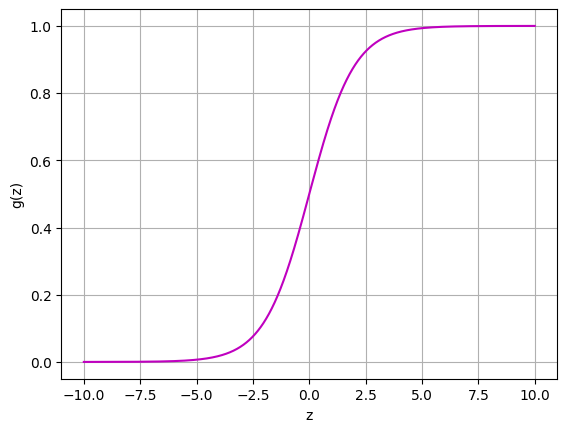

In [43]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

z = np.arange(-10,10,0.001)
gz = sigmoid(z)
plt.plot(z,gz,'m-')
plt.xlabel('z')
plt.ylabel('g(z)')
plt.grid()
plt.show()

Note that $g(z)$ tends towards 1 as $z \rightarrow \infty$, and towards 0 as $z \rightarrow -\infty$. In contrast to the step function used in the perceptron, its derivative $g^\prime (z)$ is defined everywhere 
$$
\begin{align*}
g^\prime(z) &= \frac{d}{dz}\frac{1}{1+e^{-z}} \\
&= \frac{1}{(1+e^{-z})^2}(e^{-z}) \\
&= \frac{1}{1+e^{-z}}\left( 1 - \frac{1}{1+e^{-z}}\right) \\
& = g(z)(1 - g(z)) \tag{3.20}
\end{align*}
$$

Just like the linear regression case, we want to derive a maximum likelihood estimator under a set of assumptions, and then fit the parameters $\theta$ via maximum likelihood. 
Let's assume that
$$
\begin{align*}
P(y=1 | x;\theta) &= h_\theta(x) \\
P(y=0 | x; \theta) &= 1 - h_\theta(x) \tag{3.21}
\end{align*}
$$

This can be written compactly as
$$
p(y|x;\theta) = (h_\theta(x))^y(1 - h_\theta(x))^{1-y} \tag{3.22}
$$

Assuming that the $n$ training examples were generated independently, we can then write down the likelihood of the parameters as
$$
\begin{align*}
L(\theta) &= p(y|X;\theta) \\
&= \prod_{i=1}^n p(y^{i}|x^{(i)};\theta) \\
&= \prod_{i=1}^n (h_\theta(x^{(i)}))^{y^{(i)}}(1 - h_\theta(x^{(i)}))^{1-y^{(i)}} \tag{3.23}
\end{align*}
$$

As before, it is easier to maximize the log likelihood
$$
l(\theta) = log \; L(\theta) = \sum_{i=1}^n  {y^{(i)}}log \;(h_\theta(x^{(i)})) + {1-y^{(i)}}log\;(1 - h_\theta(x^{(i)})) \tag{3.24}
$$

We can use gradient ascent to maximize the log likelihood. The updates will be given by
$$
\theta := \theta + \alpha \nabla_\theta l(\theta) \tag{3.25}
$$

Note the positive sign in (3.25), since we are maximizing the function. 

Let's start by working with one training example $(x,y)$ and take derivatives to derive the stochastic gradient ascent rule:
$$
\begin{align*}
\frac{\partial}{\partial \theta_j}l(\theta) &= \left(y\frac{1}{g(\theta^Tx)} - (1-y)\frac{1}{1-g(\theta^Tx)}\right)\frac{\partial}{\partial \theta_j}g(\theta^Tx) \\
&= \left(y\frac{1}{g(\theta^Tx)} - (1-y)\frac{1}{1-g(\theta^Tx)}\right) g(\theta^Tx)(1-g(\theta^Tx))\frac{\partial}{\partial \theta_j}g(\theta^Tx) \\
&=(y(1-g(\theta^Tx))- (1-y)g(\theta^Tx))x_j \\
&= (y - h_\theta(x))x_j \tag{3.26}
\end{align*}
$$
Above, we used (3.20). This gives us the stochastic gradient ascent rule
$$
\theta_j := \theta_j + \alpha(y^{(i)}-h_\theta(x^{(i)}))x_j^{(i)} \tag{3.27}
$$

Note that it looks identical to the previous LMS update rule, even though $h_\theta(x^{(i)})$ is different. For deeper understanding of this, see chapter 3 of [2]: Generalized linear models. 

### Example from [1] Modeling class probabilities via logistic regression 
(page 59)

!["Figure 3.3"](https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch03/figures/03_03.png)

Figure 3.3 Logistic regression compared to Adaline [1]

#### Learning the model weights via the logistic loss function

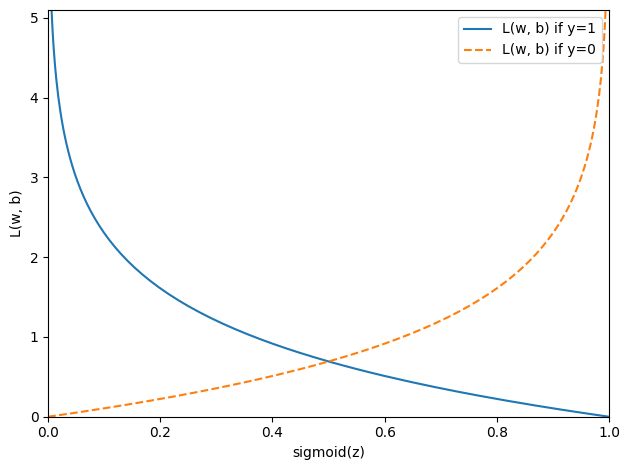

In [44]:
def loss_1(z):
    return - np.log(sigmoid(z))


def loss_0(z):
    return - np.log(1 - sigmoid(z))

z = np.arange(-10, 10, 0.1)
sigma_z = sigmoid(z)

c1 = [loss_1(x) for x in z]
plt.plot(sigma_z, c1, label='L(w, b) if y=1')

c0 = [loss_0(x) for x in z]
plt.plot(sigma_z, c0, linestyle='--', label='L(w, b) if y=0')

plt.ylim(0.0, 5.1)
plt.xlim([0, 1])
plt.xlabel('sigmoid(z)')
plt.ylabel('L(w, b)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Figure 3.4 A plot of the loss function used in logistic regression

### OOP algorithm for logistic regression

(page 66)

In [45]:
class LogisticRegressionGD:
    """Gradient descent-based logistic regression classifier.
    Modified to add step() method

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after training.
    b_ : Scalar
      Bias unit after fitting.
    losses_ : list
       Log loss function values in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []
        self.iter = 1

    def step(self, X, y):
        """ Step one epoch through training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : Instance of LogisticRegressionGD
        """
        print("Epoch : " + str(self.iter))
        net_input = self.net_input(X)
        output = self.activation(net_input)
        errors = (y - output)
        self.w_ += self.eta * X.T.dot(errors) / X.shape[0]
        self.b_ += self.eta * errors.mean()
        loss = (-y.dot(np.log(output)) - (1 - y).dot(np.log(1 - output))) / X.shape[0]
        self.losses_.append(loss)
        print("Loss = "+str(loss))
        self.iter += 1
        return self

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : Instance of LogisticRegressionGD

        """


        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_ += self.eta * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * errors.mean()
            loss = (-y.dot(np.log(output)) - (1 - y).dot(np.log(1 - output))) / X.shape[0]
            self.losses_.append(loss)

        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

Use our implementation of logistic regression to classify setosa and versicolor flowers (class 0 or 1). First load the iris dataset and standardize.

In [46]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

Class labels: [0 1 2]


In [47]:
# Splitting data into 70% training and 30% test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

In [48]:
print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


In [49]:
# Standardize the features
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

In [51]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100, 
                    label='Test set')   


In [52]:
X_train_01_subset = X_train_std[(y_train == 0) | (y_train == 1)]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1)]

In [53]:
lrgd = LogisticRegressionGD(eta=1.0, n_iter=1000, random_state=1)

Epoch : 2
Loss = 0.4707133362537819


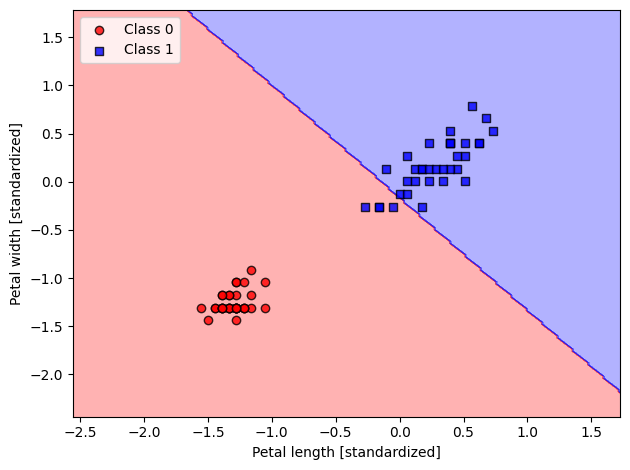

In [55]:
# step method
lrgd.step(X_train_01_subset,
         y_train_01_subset)

plot_decision_regions(X=X_train_01_subset, 
                      y=y_train_01_subset,
                      classifier=lrgd)

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

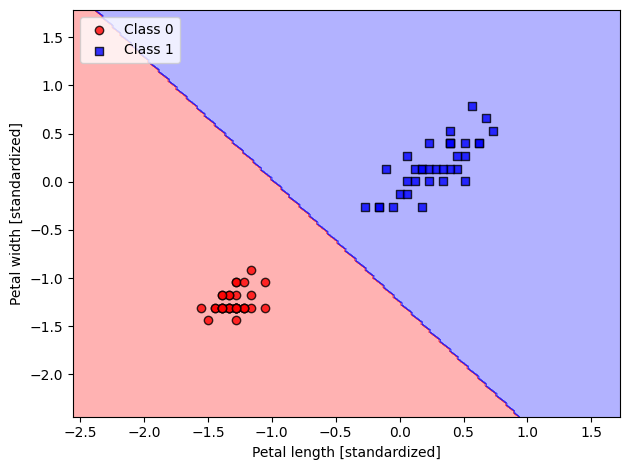

In [56]:
lrgd = LogisticRegressionGD(eta=0.3, n_iter=1000, random_state=1)
lrgd.fit(X_train_01_subset,
         y_train_01_subset)

plot_decision_regions(X=X_train_01_subset, 
                      y=y_train_01_subset,
                      classifier=lrgd)

plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### 3.3 Multi-class classification (optional)

See section 2.3 (p. 24) of [2]

#### Training a logistic regression model with scikit-learn

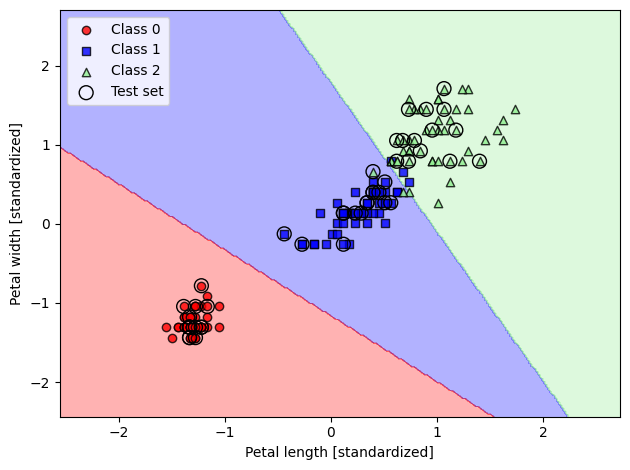

In [88]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=100.0, solver='lbfgs')
lr.fit(X_train_std, y_train)

X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))


plot_decision_regions(X_combined_std, y_combined,
                      classifier=lr, test_idx=range(105, 150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 3.4 Newton's method (optional)

See section 2.4 Another altorithm for maximizing $l(\theta)$ (p. 27) of [2]
    
### 3.5 Regularization (optional)

See section Tackling overfitting via regularization (p. 73) of [1]

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch03/figures/03_07.png" width=900 />

Figure 3.7 Examples of underfitted, well-fitted, and overfitted models [1]




### References

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022.  

2. A. Ng. [CS229 Lecture Notes.](https://cs229.stanford.edu/main_notes.pdf) Stanford University. 2023.[Related video](https://youtu.be/4b4MUYve_U8?si=qa3iBTO2R-abQViu) 

3. T. Broderick. [Introduction to Machine Learning course (6.036).](https://tamarabroderick.com/ml.html) Massachusetts Institute of Technology. 2020. [Related video](https://youtu.be/OpvrwhWEUmY?si=bS8VZYsrZMqvnuII)  



<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2025</div>